# Extract document information using Kosmos-2.5

Kosmos-2.5 is a multimodal literate model released by Microsoft for machine reading of text-intensive images. Pre-trained on large-scale text-intensive images, Kosmos-2.5 excels in two distinct yet cooperative transcription tasks: (1) generating spatially-aware text blocks, where each block of text is assigned its spatial coordinates within the image, and (2) producing structured text output that captures styles and structures into the markdown format.

In this notebook we are going to explore how to run it on a custom GPU. 

To run it on the gpu you will need at least 16.5 GB of VRAM. 

### Requirements

While I'm writing this the repo is not alligned with the transformers library version available on the master branch. 

To make this work you will need to install the following:

```bash
git+https://github.com/tic-top/transformers.git@main
```

open a terminal and run:

```bash
pip install git+https://github.com/tic-top/transformers.git@main
```

You will also need:

```
accelerate
torch
torchvision
pillow
numpy
```

### Let's get started

In [1]:
import os
os.chdir(os.getcwd()+"/pratical-llms")

#### Utils functions to load pdf from file

In [2]:
import fitz
import numpy as np

def load_pdf(pdf_path, dpi=72):
    images = []
    doc = fitz.open(pdf_path)
    for i in range(len(doc)):
        page = doc[i]
        pix = page.get_pixmap(matrix=fitz.Matrix(dpi/72, dpi/72))
        image = Image.frombytes('RGB', (pix.width, pix.height), pix.samples)

        # if width or height > 3000 pixels, don't enlarge the image
        if pix.width > 3000 or pix.height > 3000:
            pix = page.get_pixmap(matrix=fitz.Matrix(1, 1), alpha=False)
            image = Image.frombytes('RGB', (pix.width, pix.height), pix.samples)

        # images.append(image)
        images.append(np.array(image)[:,:,::-1])
    return images


#### Kosmos 2.5 wrapper class

In [3]:
import re
import torch
import requests
from PIL import Image, ImageDraw
from transformers import AutoConfig, AutoModelForVision2Seq, AutoProcessor


class KosmosModel():
    def __init__(self):
        repo = "microsoft/kosmos-2.5"
        self.device = "cuda:0"
        self.config = AutoConfig.from_pretrained(repo)
        self.dtype = torch.float16
        self.model = AutoModelForVision2Seq.from_pretrained(repo, device_map=self.device, torch_dtype=self.dtype, config=self.config)
        self.processor = AutoProcessor.from_pretrained(repo)
    
    def __call__(self,image, task, num_beams=4, max_new_tokens=2048, temperature=0.7):
        prompt = "<ocr>" if task == "OCR" else "<md>"
        inputs = self.processor(text=prompt, images=image, return_tensors="pt")

        height, width = inputs.pop("height"), inputs.pop("width")
        raw_width, raw_height = image.size
        scale_height = raw_height / height
        scale_width = raw_width / width

        inputs = {k: v.to(self.device) if v is not None else None for k, v in inputs.items()}
        inputs["flattened_patches"] = inputs["flattened_patches"].to(self.dtype)

        generated_ids = self.model.generate(
            **inputs,
            num_beams=num_beams,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
        )
        generated_text = self.processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        return self.postprocess(generated_text, scale_height, scale_width, image, prompt)

    def postprocess(self,y, scale_height, scale_width, original_image, prompt):
            y = y.replace(prompt, "")
            if "<md>" in prompt:
                return original_image, y
            pattern = r"<bbox><x_\d+><y_\d+><x_\d+><y_\d+></bbox>"
            bboxs_raw = re.findall(pattern, y)

            lines = re.split(pattern, y)[1:]
            bboxs = [re.findall(r"\d+", i) for i in bboxs_raw]
            bboxs = [[int(j) for j in i] for i in bboxs]

            info = ""

            image_with_boxes = original_image.copy()
            draw = ImageDraw.Draw(image_with_boxes)

            for i in range(len(lines)):
                box = bboxs[i]
                x0, y0, x1, y1 = box

                if not (x0 >= x1 or y0 >= y1):
                    x0 = int(x0 * scale_width)
                    y0 = int(y0 * scale_height)
                    x1 = int(x1 * scale_width)
                    y1 = int(y1 * scale_height)
                    info += f"{x0},{y0},{x1},{y0},{x1},{y1},{x0},{y1},{lines[i]}\n"

                    draw.rectangle([x0, y0, x1, y1], outline="red", width=2)

            return image_with_boxes, info


## Let's test it

In [4]:
!wget https://digitalassets.tesla.com/tesla-contents/image/upload/IR/TSLA-Q2-2024-Update.pdf

--2024-08-28 08:40:55--  https://digitalassets.tesla.com/tesla-contents/image/upload/IR/TSLA-Q2-2024-Update.pdf
Resolving digitalassets.tesla.com (digitalassets.tesla.com)... 146.75.38.92, 2a04:4e42:77::604
Connecting to digitalassets.tesla.com (digitalassets.tesla.com)|146.75.38.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6853513 (6.5M) [application/pdf]
Saving to: ‘TSLA-Q2-2024-Update.pdf’

TSLA-Q2-2024-Update 100%[===================>]   6.54M  --.-KB/s    in 0.05s   

2024-08-28 08:40:55 (140 MB/s) - ‘TSLA-Q2-2024-Update.pdf’ saved [6853513/6853513]



In [5]:
data_path = "TSLA-Q2-2024-Update.pdf"

In [6]:
images = load_pdf(data_path)

In [7]:
kosmos_model = KosmosModel()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [100260, 100265, 100266, 100267, 100268, 100269, 100270, 100271, 100272, 100273, 100274, 100275, 100276, 100277, 100278, 100279, 100281], your vocabulary could be corrupted !


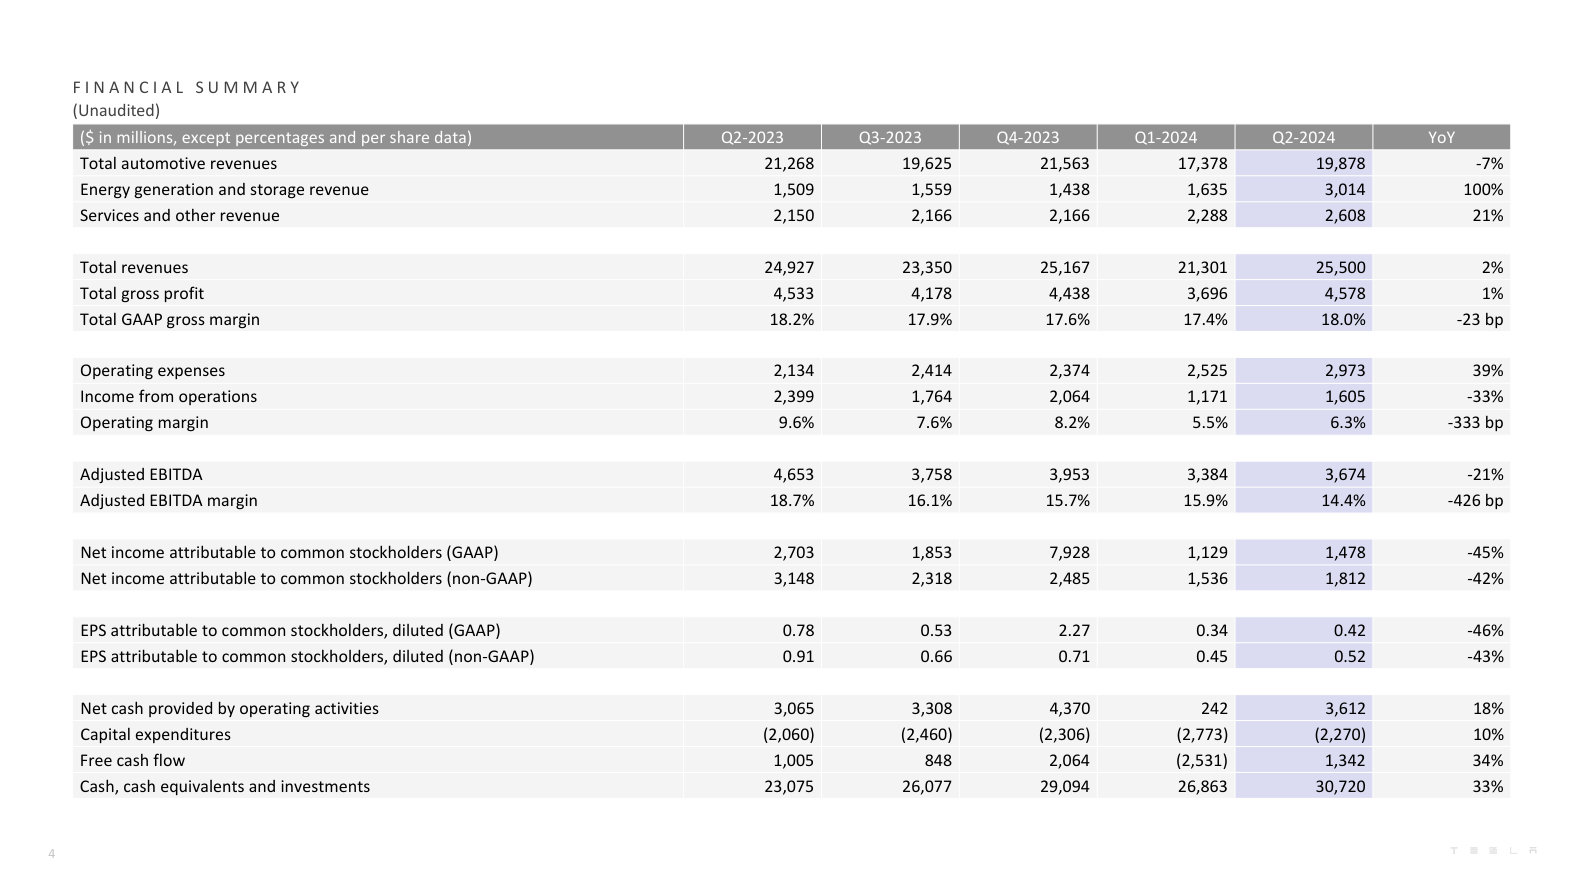

In [8]:
img = Image.fromarray(images[3])
img.show()

The image have a well strucutured table. Let's see how the model perform

In [9]:
result = kosmos_model(img,task="<md>") ### everything excpet "OCR" will use the MD version
print(result[1])

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


&gt; F I N A N C I A L S U M M A R Y
&gt;
&gt; (Unaudited)

<table>
<colgroup>
<col/>
<col/>
<col/>
<col/>
<col/>
<col/>
<col/>
</colgroup>
<thead>
<tr>
<th>
(S in millions, except percentages and per share data)
</th>
<th>
Q2-2023
</th>
<th>
Q3-2023
</th>
<th>
Q4-2023
</th>
<th>
Q1-2024
</th>
<th>
Q2-2024
</th>
<th>
YoY
</th>
</tr>
</thead>
<tbody>
<tr>
<td>
Total automotive revenues
</td>
<td>
21,268
</td>
<td>
19,625
</td>
<td>
21,563
</td>
<td>
17,378
</td>
<td>
19,878
</td>
<td>
-7%
</td>
</tr>
<tr>
<td>
Energy generation and storage revenue
</td>
<td>
1,509
</td>
<td>
1,559
</td>
<td>
1,438
</td>
<td>
1,635
</td>
<td>
3,014
</td>
<td>
100%
</td>
</tr>
<tr>
<td>
Services and other revenue
</td>
<td>
2,150
</td>
<td>
2,166
</td>
<td>
2,166
</td>
<td>
2,288
</td>
<td>
2,608
</td>
<td>
21%
</td>
</tr>
<tr>
<td>
Total revenues
</td>
<td>
24,927
</td>
<td>
23,350
</td>
<td>
25,167
</td>
<td>
21,301
</td>
<td>
25,500
</td>
<td>
2%
</td>
</tr>
<tr>
<td>
Total gross profit
</td>
<td>
4,53

#### Seems great. Let's render it to see the results better

In [10]:
from IPython.core.display import display, HTML
display(HTML(result[1]))

/tmp/ipykernel_74653/3995486629.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


"(S in millions, except percentages and per share data)",Q2-2023,Q3-2023,Q4-2023,Q1-2024,Q2-2024,YoY
Total automotive revenues,"21,268","19,625","21,563","17,378","19,878",-7%
Energy generation and storage revenue,"1,509","1,559","1,438","1,635","3,014",100%
Services and other revenue,"2,150","2,166","2,166","2,288","2,608",21%
Total revenues,"24,927","23,350","25,167","21,301","25,500",2%
Total gross profit,"4,533","4,178","4,438","3,696","4,578",1%
Total GAAP gross margin,18.2%,17.9%,17.6%,17.4%,18.0%,-23 bp
Operating expenses,"2,134","2,414","2,374","2,525","2,973",39%
Income from operations,"2,399","1,764","2,064","1,171","1,605",-33%
Operating margin,9.6%,7.6%,8.2%,5.5%,6.3%,-333 bp
Adjusted EBITDA,"4,653","3,758","3,953","3,384","3,674",-21%


#### This one is perfect. Let's try to transform the entire document.

This will take a lot of time. In a real world application I would use an hybrid approach, using this model only in specific scenarios or specific page where I need to be really precise.

For the purpose I will choose some pages from the document. 

In [16]:
!pip install ipyplot

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


### If you want to plot the image inside the document run the following cell.
I deleted the output; otherwise, the notebook would have been too large to display on GitHub.

In [ ]:
import ipyplot

ipyplot.plot_images(images, max_images=30, img_width=150)

### Let's take the number 2,3,4,5,6,8,9, 22,23 and 26

In [19]:
sample_index = [2,3,4,5,6,8,9,22,23,26]
sample = [images[i] for i in sample_index]

In [20]:
results = []
for i,im in zip(sample_index,sample):
    t = Image.fromarray(im)
    r = kosmos_model(t,task="<md>")
    results.append({"page":i,"text":r[1]})
    print(f"Page {i} completed")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


Page 2 completed
Page 3 completed
Page 4 completed
Page 5 completed
Page 6 completed
Page 8 completed
Page 9 completed
Page 22 completed
Page 23 completed
Page 26 completed


In [24]:
for r in results:
    display(HTML(f"<p>Page: {r['page']}</p>"))
    display(HTML(r['text']))
    display("----------------")

H I G H L I G H T S,S U M M A R Y


'----------------'

"(S in millions, except percentages and per share data)",Q2-2023,Q3-2023,Q4-2023,Q1-2024,Q2-2024,YoY
Total automotive revenues,"21,268","19,625","21,563","17,378","19,878",-7%
Energy generation and storage revenue,"1,509","1,559","1,438","1,635","3,014",100%
Services and other revenue,"2,150","2,166","2,166","2,288","2,608",21%
Total revenues,"24,927","23,350","25,167","21,301","25,500",2%
Total gross profit,"4,533","4,178","4,438","3,696","4,578",1%
Total GAAP gross margin,18.2%,17.9%,17.6%,17.4%,18.0%,-23 bp
Operating expenses,"2,134","2,414","2,374","2,525","2,973",39%
Income from operations,"2,399","1,764","2,064","1,171","1,605",-33%
Operating margin,9.6%,7.6%,8.2%,5.5%,6.3%,-333 bp
Adjusted EBITDA,"4,653","3,758","3,953","3,384","3,674",-21%


'----------------'

'----------------'

...

'----------------'

In millions of USD,30-Jun-23,30-Sep-23,31-Dec-23,31-Mar-24,30-Jun-24
ASSETS,,,,,
Current assets,,,,,
"Cash, cash equivalents and investments","23,075","26,077","29,094","26,863","30,720"
"Accounts receivable, net","3,447","2,520","3,508","3,887","3,737"
Inventory,"14,356","13,721","13,626","16,033","14,195"
Prepaid expenses and other current assets,"2,997","2,708","3,388","3,752","4,325"
Total current assets,"43,875","45,026","49,616","50,535","52,977"
"Operating lease vehicles, net","5,935","6,119","5,989","5,736","5,541"
"Solar energy systems, net","5,365","5,293","5,229","5,162","5,102"
"Property, plant and equipment, net","26,389","27,744","29,725","31,436","32,960"


'----------------'

In millions of USD,4Q-2020,1Q-2021,2Q-2021,3Q-2021,4Q-2021,1Q-2022,2Q-2022,3Q-2022,4Q-2022,1Q-2023,2Q-2023,3Q-2023,4Q-2023,1Q-2024,2Q-2024
Net cash provided by operating activities (GAAP),"3,019","1,641","2,124","3,147","4,585","3,995","2,351","5,100","3,278","2,513","3,065","3,308","4,370",242,"3,612"
Capital expenditures,"(1,151)","(1,348)","(1,505)","(1,819)","(1,810)","(1,767)","(1,730)","(1,803)","(1,858)","(2,072)","(2,060)","(2,460)","(2,306)","(2,773)","(2,270)"
Free cash flow (non-GAAP),"1,868",293,619,"1,328","2,775","2,228",621,"3,297","1,420",441,"1,005",848,"2,064","(2,531)","1,342"
In millions of USD,4Q-2020,1Q-2021,2Q-2021,3Q-2021,4Q-2021,1Q-2022,2Q-2022,3Q-2022,4Q-2022,1Q-2023,2Q-2023,3Q-2023,4Q-2023,1Q-2024,2Q-2024
Net income attributable to common stockholders (GAAP),270,438,"1,142","1,618","2,321","3,318","2,259","3,292","3,687","2,513","2,703","1,853","7,928","1,129","1,478"
Interest expense,246,99,75,126,71,61,44,53,33,29,28,38,61,76,86
Provision for (benefit from) income taxes,83,69,115,223,292,346,205,305,276,261,323,167,"(5,752)",409,393
"Depreciation, amortization and impairment",618,621,681,761,848,880,922,956,989,"1,046","1,154","1,235","1,232","1,246","1,278"
Stock-based compensation expense,633,614,474,475,558,418,361,362,419,418,445,465,484,524,439
Adjusted EBITDA (non-GAAP),"1,850","1,841","2,487","3,203","4,090","5,023","3,791","4,968","5,404","4,267","4,653","3,758","3,953","3,384","3,674"


'----------------'

## I don't know what you think but if you ask me the results are staggering